In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import os

from sksurv.nonparametric import kaplan_meier_estimator



In [39]:
#download GEO data
# all datasets are GSE21050, GSE30929, and GSE71118

gse = GEOparse.get_GEO(geo="GSE21050", destdir="./data", silent=True)

c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


In [46]:
table = gse.gpls["GPL570"].table

In [48]:
table.to_csv("./data/GPL570_annotation.csv")

In [ ]:
pivoted_control_samples = gse.pivot_samples('VALUE')
pivoted_control_samples.head()

name,GSM525806,GSM525807,GSM525808,GSM525809,GSM525810,GSM525811,GSM525812,GSM525813,GSM525814,GSM525815,...,GSM526106,GSM526107,GSM526108,GSM526109,GSM526110,GSM526111,GSM526112,GSM526113,GSM526114,GSM526115
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,106.15,108.38,199.47,195.36,192.67,47.84,337.79,101.83,151.17,145.01,...,151.17,129.79,135.30,128.89,94.35,116.16,501.46,481.04,60.13,120.26
1053_at,91.77,121.10,177.29,118.60,94.35,116.97,99.73,186.11,80.45,249.00,...,82.14,128.89,65.34,158.68,268.73,118.60,103.25,131.60,171.25,88.65
117_at,108.38,107.63,357.05,121.94,11.47,151.17,77.71,22.16,73.01,191.34,...,75.58,198.09,38.05,86.22,240.52,224.41,126.24,35.75,112.99,1448.15
121_at,6.68,8.51,4.76,9.65,4.53,8.75,4.66,4.66,4.79,4.59,...,4.66,31.56,4.59,16.68,13.27,5.54,5.03,4.69,4.56,22.78
1255_g_at,4.26,4.23,4.29,4.35,4.29,4.26,4.29,4.26,4.32,4.26,...,4.35,4.23,4.32,4.41,4.32,4.32,4.26,4.35,4.29,4.44


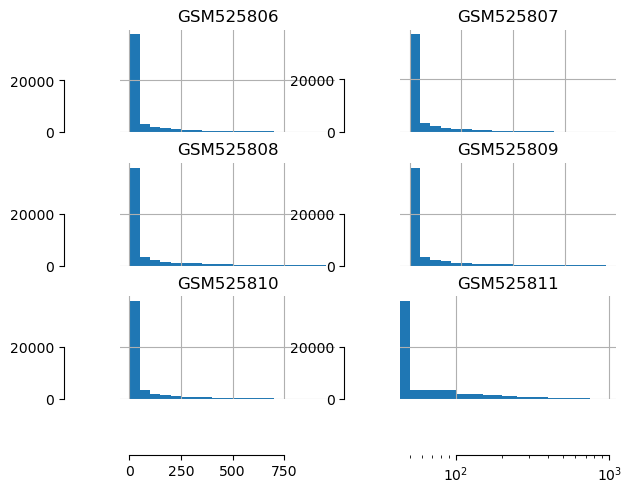

In [ ]:
# plot first 5 samples
pivoted_control_samples.iloc[:, :6].hist(bins=[i for i in range(0, 1000, 50)])
plt.xscale('log')
sns.despine(offset=40, trim=True)

In [ ]:
# get all the metadata
metadata = gse.phenotype_data
print(metadata.head())

                   title geo_accession                 status submission_date  \
GSM525806    S1_cohort 1     GSM525806  Public on Jun 30 2010     Mar 24 2010   
GSM525807   S10_cohort 1     GSM525807  Public on Jun 30 2010     Mar 24 2010   
GSM525808  S100_cohort 1     GSM525808  Public on Jun 30 2010     Mar 24 2010   
GSM525809  S101_cohort 1     GSM525809  Public on Jun 30 2010     Mar 24 2010   
GSM525810  S102_cohort 1     GSM525810  Public on Jun 30 2010     Mar 24 2010   

          last_update_date type channel_count source_name_ch1  organism_ch1  \
GSM525806      Sep 24 2012  RNA             1  Internal trunk  Homo sapiens   
GSM525807      Sep 24 2012  RNA             1     Extremities  Homo sapiens   
GSM525808      Sep 24 2012  RNA             1     Extremities  Homo sapiens   
GSM525809      Sep 24 2012  RNA             1     Extremities  Homo sapiens   
GSM525810      Sep 24 2012  RNA             1     Extremities  Homo sapiens   

          taxid_ch1  ...  contact_inst

(array([142.,  64.,  30.,  19.,  23.,   9.,  10.,   7.,   2.,   3.]),
 array([ 0.  ,  1.85,  3.7 ,  5.55,  7.4 ,  9.25, 11.1 , 12.95, 14.8 ,
        16.65, 18.5 ]),
 <BarContainer object of 10 artists>)

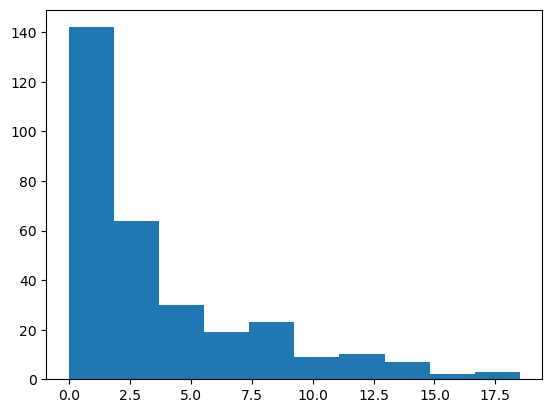

In [ ]:
times = metadata['characteristics_ch1.4.time']
plt.hist(times.astype(float))

In [ ]:
#use scikit-survival to make survival curves



In [10]:
#data = metadata[['characteristics_ch1.3.metastasis', 'characteristics_ch1.4.time']]

metastasis_map = {'yes': True, 'no': False}

data = pd.DataFrame()
data['metastasis'] = metadata['characteristics_ch1.3.metastasis'].map(metastasis_map).astype(bool)
data['time'] = metadata['characteristics_ch1.4.time'].astype(float)

data = data.dropna()

time, survival_prob, conf_int = kaplan_meier_estimator(
    data['metastasis'], data['time'], conf_type="log-log"
)
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

NameError: name 'metadata' is not defined

In [ ]:
data.head()

,metastasis,time
GSM525806,False,9.00
GSM525807,True,1.22
GSM525808,True,0.92
GSM525809,True,1.48
GSM525810,False,0.21


In [ ]:
metadata['characteristics_ch1.2.cinsarc group']

GSM525806    C1
GSM525807    C2
GSM525808    C2
GSM525809    C2
GSM525810    C2
             ..
GSM526111    C1
GSM526112    C1
GSM526113    C2
GSM526114    C1
GSM526115    C2
Name: characteristics_ch1.2.cinsarc group, Length: 310, dtype: object

In [ ]:
metadata['characteristics_ch1.5.diagnosis'].unique()

array(['Liposarcoma - dedifferentiated', 'Leiomyosarcoma',
       'Undifferentiated sarcoma', 'Other', nan], dtype=object)

In [ ]:
# filter for liposarcoma - dedifferentiated
lipo_metadata = metadata[ metadata['characteristics_ch1.5.diagnosis'] == 'Liposarcoma - dedifferentiated' ]
lipo_metadata.shape

(62, 40)

In [ ]:
# and get gene expression for those samples
lipo_samples = lipo_metadata['geo_accession'].tolist()
lipo_data = gse.pivot_samples('VALUE')[lipo_samples]
lipo_data.shape

(54613, 62)

In [ ]:
# save lipo_data to csv
lipo_data.to_csv('./data/liposarcoma_dedifferentiated_expression.csv')
lipo_metadata.to_csv('./data/liposarcoma_dedifferentiated_metadata.csv')

In [ ]:
# relaod data
lipo_data = pd.read_csv('./data/liposarcoma_dedifferentiated_expression.csv', index_col=0)
lipo_metadata = pd.read_csv('./data/liposarcoma_dedifferentiated_metadata.csv', index_col=0)

Text(0.5, 1.0, 'Liposarcoma - Dedifferentiated estimated matastasis-free survival')

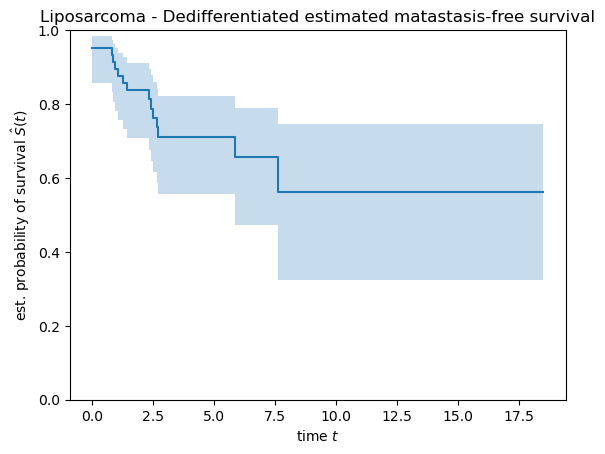

In [11]:
# make survival curve for liposarcoma - dedifferentiated
metastasis_map = {'yes': True, 'no': False}

lipo_survival = pd.DataFrame()
lipo_survival['metastasis'] = lipo_metadata['characteristics_ch1.3.metastasis'].map(metastasis_map).astype(bool)
lipo_survival['time'] = lipo_metadata['characteristics_ch1.4.time'].astype(float)

lipo_survival = lipo_survival.dropna()

time, survival_prob, conf_int = kaplan_meier_estimator(
    lipo_survival['metastasis'], lipo_survival['time'], conf_type="log-log"
)
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.title("Liposarcoma - Dedifferentiated estimated matastasis-free survival")

# survival model

In [12]:
# for now I will just use the forest model from scikit-survival
from sksurv.ensemble import RandomSurvivalForest


In [13]:
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sksurv.datasets import load_gbsg2
from sksurv.ensemble import RandomSurvivalForest
from sksurv.preprocessing import OneHotEncoder

set_config(display="text")  # displays text representation of estimators

In [14]:
from sksurv.util import Surv

In [15]:

y = Surv.from_arrays(event=lipo_survival['metastasis'], time=lipo_survival['time'])

X = lipo_data.transpose()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, train_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Initialize and fit Random Survival Forest
rsf = RandomSurvivalForest(
    n_estimators=100,           # Number of trees
    min_samples_split=10,       # Minimum samples to split a node
    min_samples_leaf=5,         # Minimum samples in a leaf
    max_features='sqrt',        # Number of features to consider for splitting
    n_jobs=-1,                  # Use all available cores
    random_state=42
)

In [19]:
# to many features, will just use first 50 for now
X_train_scaled_mini = X_train_scaled[:, :50]
X_test_scaled_mini = X_test_scaled[:, :50]

In [20]:
print("Fitting Random Survival Forest...")
rsf.fit(X_train_scaled_mini, y_train)

# Evaluate model performance (C-index)
train_score = rsf.score(X_train_scaled_mini, y_train)
test_score = rsf.score(X_test_scaled_mini, y_test)

print(f"\nModel Performance (C-index):")
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")



Fitting Random Survival Forest...

Model Performance (C-index):
Training score: 0.9286
Testing score: 0.5652


In [26]:
# get feature importances
# rsf.feature_importances_ is not implemented for RandomSurvivalForest
# they suggest using permutation importance instead
from sklearn.inspection import permutation_importance

result = permutation_importance(rsf, X_test_scaled_mini, y_test, n_repeats=15, random_state=42)

In [27]:
pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns[0:50],
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
ID_REF,,
1552257_a_at,0.113043,0.052174
1053_at,0.086957,0.038888
1552303_a_at,0.014493,0.040992
1007_s_at,0.000000,0.000000
1255_g_at,0.000000,0.000000
117_at,0.000000,0.000000
1316_at,0.000000,0.000000
1320_at,0.000000,0.000000
1405_i_at,0.000000,0.000000


C-index = 1.0: Perfect prediction - the model always correctly orders patients by risk
C-index = 0.5: Random prediction - no better than flipping a coin
C-index = 0.0: Perfect inverse prediction - the model gets the ordering completely backwards

In [32]:
import numpy as np
from sksurv.linear_model import CoxPHSurvivalAnalysis

def fit_and_score_features(X, y):
    n_features = X.shape[1]
    scores = np.empty(n_features)
    # Fit a CoxPH model for each feature
    for j in range(n_features):
        Xj = X[:, j : j + 1] # Select one feature
        try:
            m = CoxPHSurvivalAnalysis()
            m.fit(Xj, y)
            scores[j] = m.score(Xj, y) # Use concordance index as the score
        except Exception as e:
            scores[j] = 0.0
    return scores
feature_scores = fit_and_score_features(X_train_scaled, y_train)

c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\sksurv\linear_model\coxph.py:200: RuntimeWarning: overflow encountered in exp
  risk_set += np.exp(xw[k])
c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\sksurv\linear_model\coxph.py:197: RuntimeWarning: overflow encountered in exp
  risk_set2 += np.exp(xw[k])
c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\sksurv\linear_model\coxph.py:200: RuntimeWarning: overflow encountered in scalar add
  risk_set += np.exp(xw[k])
c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\sksurv\linear_model\coxph.py:254: RuntimeWarning: overflow encountered in scalar add
  risk_set += exp_xw[k]
c:\Users\sherh\anaconda3\envs\bf550-final-env\lib\site-packages\sksurv\linear_model\coxph.py:205: RuntimeWarning: overflow encountered in scalar add
  risk_set += risk_set2
C:\Users\sherh\AppData\Local\Temp\ipykernel_26932\2821028932.py:12: ConvergenceWarning: Optimization did not converge: Maximum number of

(array([  174.,    16.,   155.,   270.,   318.,   911.,   227.,  1435.,
         2194.,   451.,  4506.,  5061.,  6339.,  1724.,  7303., 11127.,
         6132.,  4709.,  1242.,   319.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

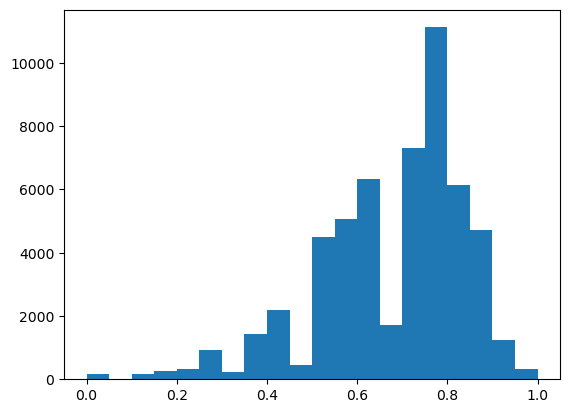

In [35]:
plt.hist(feature_scores, bins=20)

In [38]:
# get top 200 features
top_200_indices = np.argsort(feature_scores)[-200:]

#and thier corresponding gene names
top_200_genes = X_train.columns[top_200_indices]

top_200_genes


Index(['238243_at', '244236_at', '217019_at', '234068_s_at', '216795_at',
       '220842_at', '220869_at', '243324_x_at', '212706_at', '1568934_at',
       ...
       '239744_at', '232355_at', '35265_at', '237118_at', '214947_at',
       '238933_at', '239012_at', '242699_at', '242645_at', '1438_at'],
      dtype='object', name='ID_REF', length=200)

In [50]:
table.loc[table['ID'].isin(top_200_genes)].to_csv('./data/top_200_genes_annotation.csv')

In [55]:
# add feature score to table
#table['feature_score'] = feature_scores
feature_names = X.columns

score_df = pd.DataFrame({'id': feature_names, 'feature_score': feature_scores})

In [56]:
#merge score_df with table on 'id' and 'ID'
merged_df = pd.merge(table, score_df, left_on='ID', right_on='id', how='left')

In [57]:
merged_df.to_csv('./data/gene_feature_scores_annotation.csv')

# Next steps
* run random forest on selected genes